In [31]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [32]:
#load/read data

In [33]:
sample_data = pd.read_json("B2C_Sample_Dataset.json")
print("Reading file....",sample_data.head())
print(" structure of dataframe",sample_data.info())
print("distinct values in gender--",sample_data['user_id'].unique())
# info function tells there are missing values in monthly_sessions column, decide if we need imputation vs deleting the record





Reading file....   user_id  age  gender state region plan_type  signup_channel  \
0  U00001   42    Male    CA   West      Free         Organic   
1  U00002   29    Male    TN  South   Premium         Organic   
2  U00003   30  Female    CA   West      Free  Paid_Marketing   
3  U00004   37  Female    TX  South   Premium  Paid_Marketing   
4  U00005   29  Female    VA  South   Premium         Organic   

   activedays_per_week  months_since_signup  monthly_sessions  cust_ltv  
0                    3                   10              15.0      5.10  
1                    1                    1               0.0     14.51  
2                    2                    3              19.0      2.20  
3                    0                    1               0.0      1.85  
4                    0                   19               0.0      0.00  
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
--

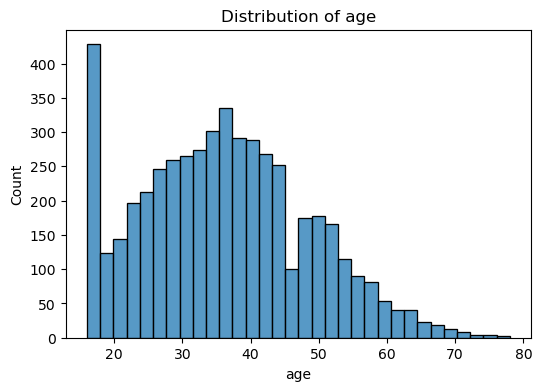

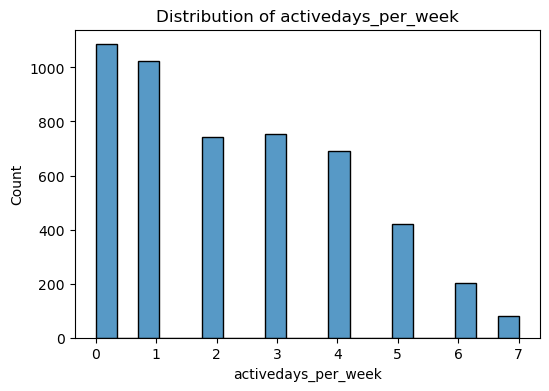

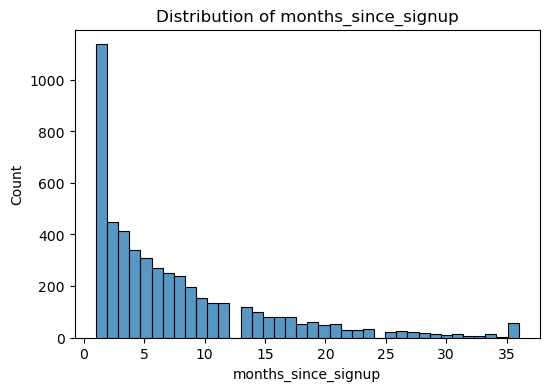

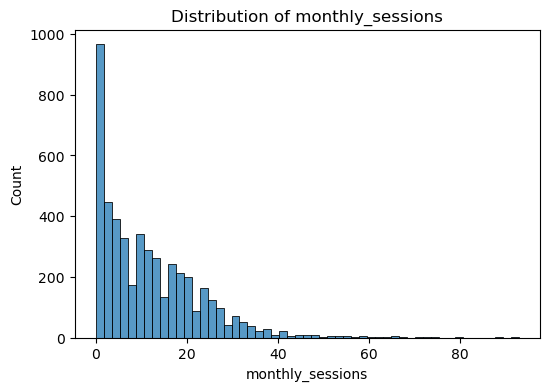

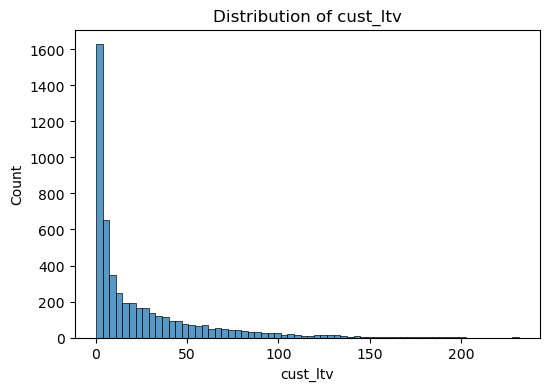

In [34]:
# Univariate EDA for numeric variables 
#build histogram
numeric_cols=['age','activedays_per_week','months_since_signup','monthly_sessions','cust_ltv']

for col in numeric_cols:
   plt.figure(figsize=(6,4))
   sns.histplot(sample_data[col])
   plt.title('Distribution of ' + col)
   plt.show()
  

In [35]:
#monthly_sessions , months_since_signup and cust_ltv are right skewed.
#TARGET VARIABLE CUST_LTV is right skewed. we need to do a log transform.

gender
Male          2473
Female        2433
Non-binary      94
Name: count, dtype: int64


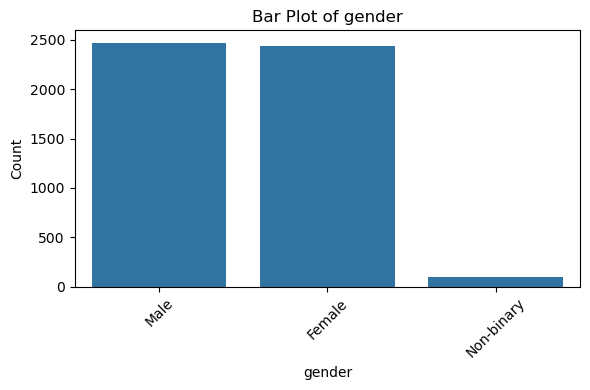

region
South        1947
West         1177
Midwest       991
Northeast     885
Name: count, dtype: int64


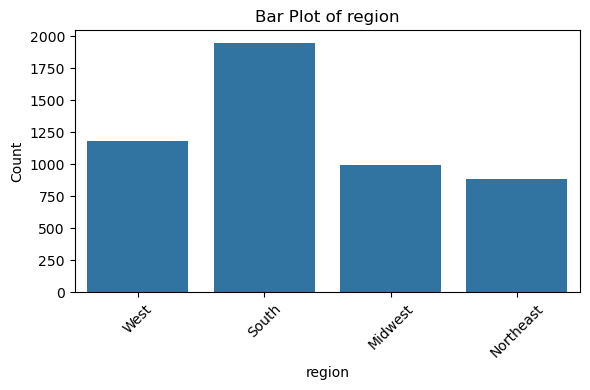

plan_type
Free       1905
Basic      1473
Premium    1089
Family      533
Name: count, dtype: int64


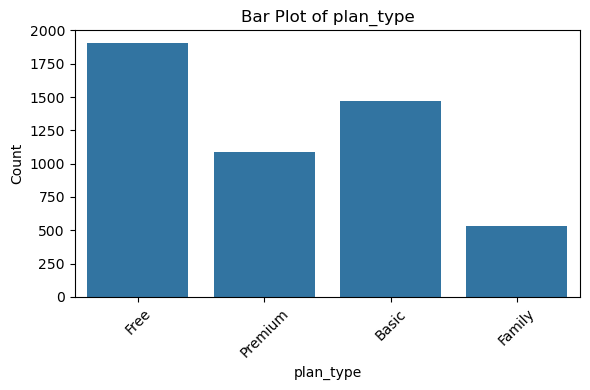

signup_channel
Organic           2319
Paid_Marketing    1901
Referral           780
Name: count, dtype: int64


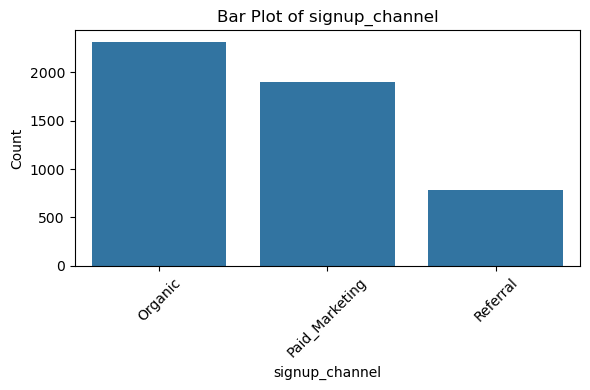

In [36]:
#UNIVARIATE EDA - CATEGORICAL VARIABLES
#bar plots
cat_cols = ['gender','region','plan_type','signup_channel']
for col in cat_cols:
  print(sample_data[col].value_counts())
  plt.figure(figsize=(6,4))
  sns.countplot(x=sample_data[col])
  plt.title(f"Bar Plot of {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

In [37]:
#BI-VARIATE ANALYSIS
#SCATTERPLOTS FOR NUMERIC VARIABLES VS TARGET

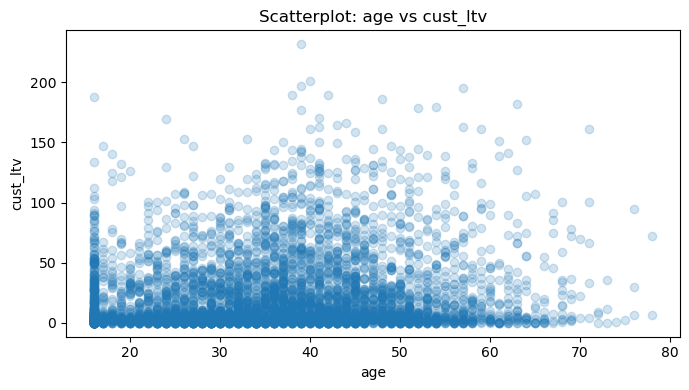

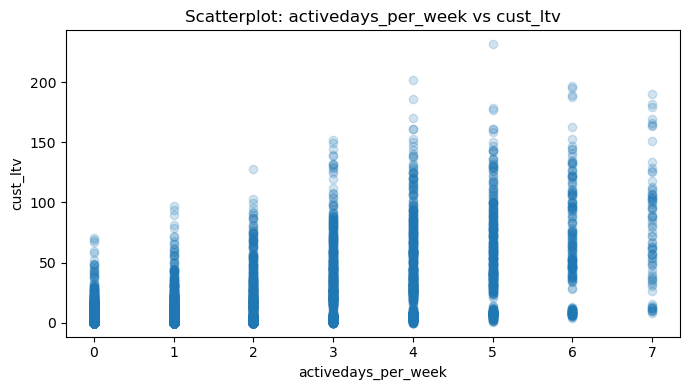

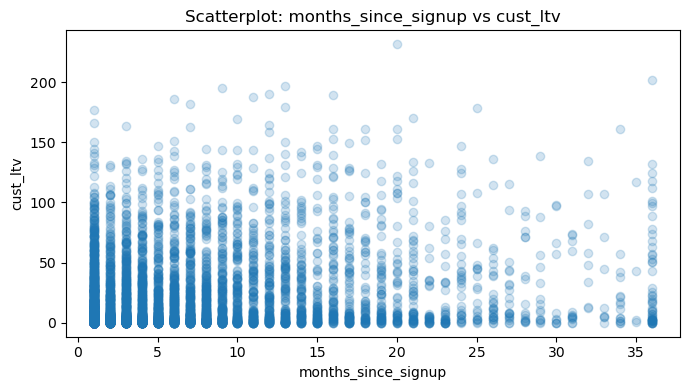

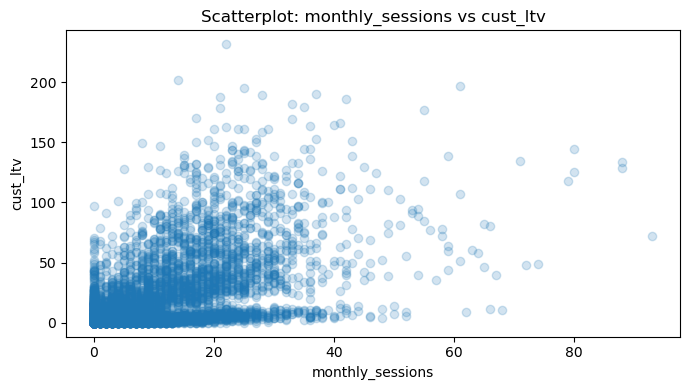

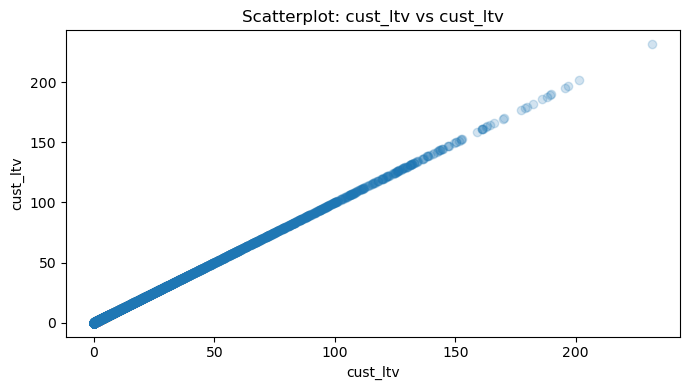

In [38]:
TARGET_COL = "cust_ltv"
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    plt.scatter(col, TARGET_COL, alpha=0.2,data=sample_data)
    plt.xlabel(col)
    plt.ylabel(TARGET_COL)
    plt.title(f"Scatterplot: {col} vs {TARGET_COL}")
    plt.tight_layout()
    plt.show()

In [39]:
#scatter plot - monthly_sessions vs ltv
#shows - monthly_sessions is positively correlated to customer LTV. A dense cluster is near ltv=0 indicates that there are zero-inflated users. Users who took a 
#free plan,opened the app but never converted.
# heavy cluster of users are between 0-25 monthly sessions, with a thin cluster for 45+monthly sessions, indicates these folks are less but generates high LTV.
#relationship is non-linear, needs a log transform the cust_ltv variable.

#active_daya per week  vs ltv
# shows a positive trend
# dense bottom values near 0 dollar ltv even for 5+ active days/week shows high engagement alone does not drive ltv.
#A free plan user active every day , if not converted to a paid plan will not drive LTV., implies plan type drives LTV.

#age vs cust_ltv
# a rectangular plot with no clear trend. indicates that age does not directly affect the ltv

#months_since sign up vs ltv - slight positive . dense towards 0-15 months indicates for first few months a lot of customers signing up and as months grow
#for 40+ months very few customers are there.Implies loyalty matters for LTV. 




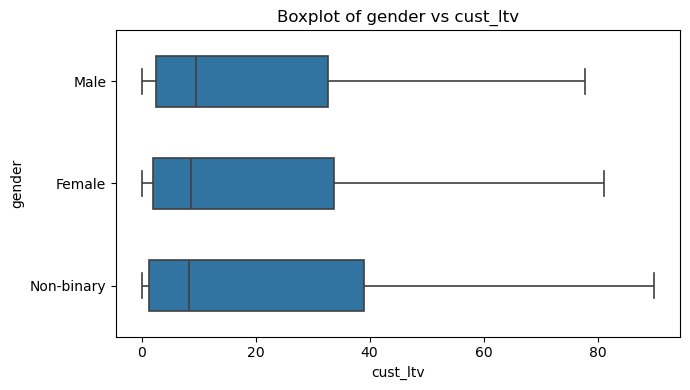

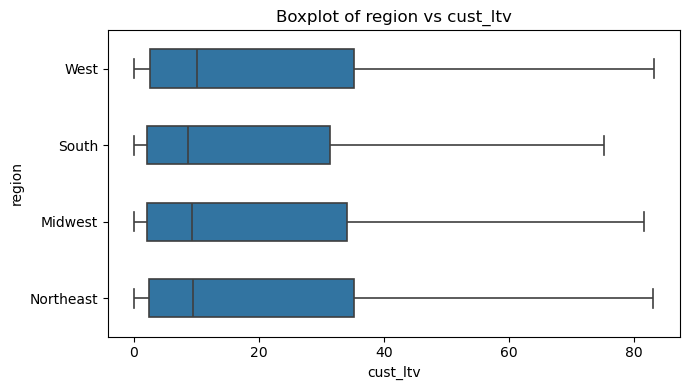

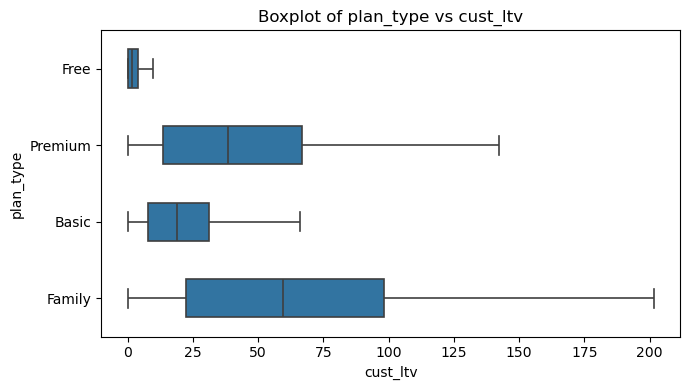

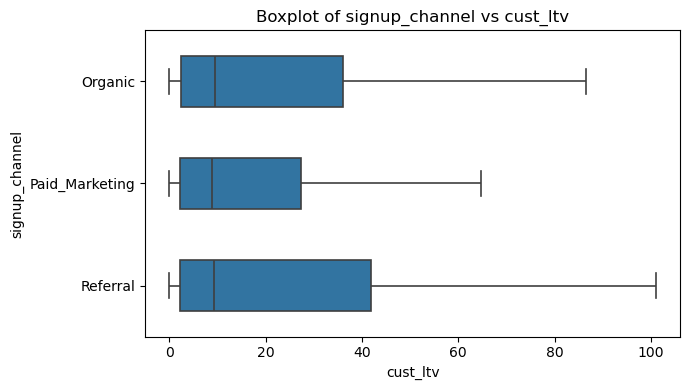

In [40]:
# BI-VARIATE ANALYSIS CATEGORICAL VS TARGET
#Our target variable is right skewed, so box and whisker is a good choice as it will show spread around the mean.

for col in cat_cols:
  plt.figure(figsize=(7,4))
  sns.boxplot(x=TARGET_COL,y=col,data=sample_data,width=0.5,linewidth=1.2,showfliers=False)
  plt.title(f"Boxplot of {col} vs {TARGET_COL}")
  plt.xlabel(TARGET_COL)
  plt.ylabel(col)
  plt.tight_layout()
  plt.show()


In [41]:
#key insights from Box and Whisker plots
# gender vs ltv - median is same for all 3 genders.Q1 and Q3 are roughly the same and there is minor difference in the whiskers for non-binary.
# Since non-binary count = 94 in a 5k dataset, its a statistical noise and not something significant.
# gender does not affect LTV

# region vs cust_ltv
# q1,q2,q3 nearly same. max differs by 3-5usd which is neglible.
# region has no impact on LTV.

#plan_type vs ltv
# the difference in min and max from free plan to family plan is huge.from 10-20usd in free plan to 200usd+in family plan.
# Q1,Q2,Q3 also vary significantly. Plan_type is largely impacting LTV.
#if a customer retains for x months, LTV compunds drastically for higher priced plans.


# signup channel vs ltv - q1,q2 are same. min is around 2$,q3 for referral is highest followed by organic and paid.
#max for referral is highest at 110$ followed by organic at 80$ and paid marketing around 75.
# referral generates the highest LTV. Customers built on trust and referrals by current customers tend to stay longer.


                          age  activedays_per_week  months_since_signup  \
age                  1.000000            -0.001984            -0.012088   
activedays_per_week -0.001984             1.000000             0.003470   
months_since_signup -0.012088             0.003470             1.000000   
monthly_sessions     0.000796             0.842707            -0.003192   
cust_ltv             0.128500             0.553237             0.153989   

                     monthly_sessions  cust_ltv  
age                          0.000796  0.128500  
activedays_per_week          0.842707  0.553237  
months_since_signup         -0.003192  0.153989  
monthly_sessions             1.000000  0.510157  
cust_ltv                     0.510157  1.000000  


<Axes: >

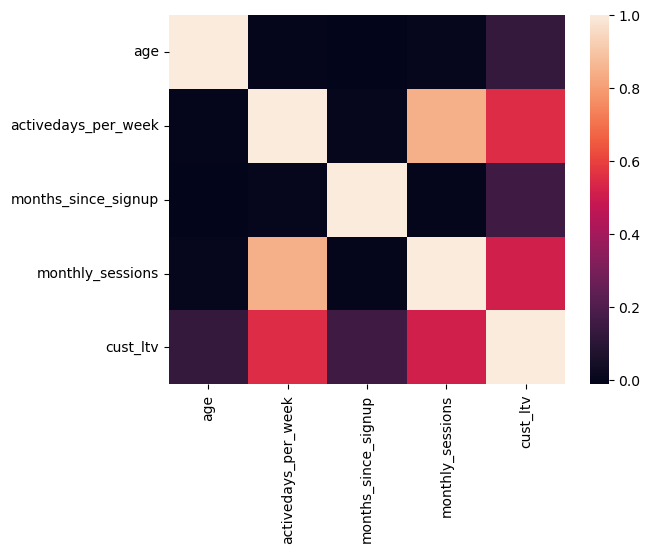

In [42]:
# check multi-collinearity between variables .build correlation table for all numeric variables
## correlation matrix


corr_table=sample_data.select_dtypes(include="number").corr()
print(corr_table)
sns.heatmap(corr_table)

In [43]:
# KEY INSIGHTS FROM EDA 

In [44]:
# 1.Target variable is right skewed,indicates few users contribute to maximum LTV which applies to a real world SAAS B2C freemium business model. key statistic insight is needs to apply log for linear regression.
# 2. Age, state,region has no impact on LTV contribution.
# 3. Active days/week and monthly sessions are the strongest drivers impacting ltv.High engagement combined with longer retention period contributes to max ltv.
# 4. Dense clusters around 0$ LTV implies high engagement alone is not effective for ltv as Free plan users could enagage mostly churn off without conversion leading to minimum to 0 LTV.
# 5. A typical Paid plans drive maximum LTV of over 100 USD vs free plan at only 8$.
# 6. Sparse scatter plot shows very few users are with fAMILY plans driving the maximum ltv, implies that 20% of population derives 80% of value.(80/20 Rule)
# 7. Referrals drive the maximum LTV, while paid marketing is the least driving factor,implies spending on Loyalty programs and referral programs could significantly help increase LTV.
# 8. A classic upsell business model, focused on value driven selling by encouraging customers to purchase a higher end premium version of product, reducing Customer Acquision cost.


In [45]:
#deal missing values
# since monthly_sessions have strong correlation with ltv, we impute the missing data and not delete the records
#since data is right skewed, find median
plan_medians = sample_data.groupby("plan_type")["monthly_sessions"].median()

#impute
sample_data["monthly_sessions"] = sample_data["monthly_sessions"].fillna(
    sample_data["plan_type"].map(plan_medians)
)
print(sample_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              5000 non-null   str    
 1   age                  5000 non-null   int64  
 2   gender               5000 non-null   str    
 3   state                5000 non-null   str    
 4   region               5000 non-null   str    
 5   plan_type            5000 non-null   str    
 6   signup_channel       5000 non-null   str    
 7   activedays_per_week  5000 non-null   int64  
 8   months_since_signup  5000 non-null   int64  
 9   monthly_sessions     5000 non-null   float64
 10  cust_ltv             5000 non-null   float64
dtypes: float64(2), int64(3), str(6)
memory usage: 429.8 KB
None


In [46]:
# PARTITION DATA TO AVOID OVERFITTING

print(TARGET_COL)
#user_id and state has high collinearity , not significant for prediction drop them. they are not feature variables
cols_to_drop = ['user_id','state']
sample_afterdrop = sample_data.drop(columns=cols_to_drop)
print(sample_afterdrop)

#separate target from feature variables
X = sample_afterdrop.drop(columns=[TARGET_COL])
print(X)
y = np.log1p(sample_afterdrop[TARGET_COL]) 

#split data into train and test(60/40)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training sample::",X_train)



cust_ltv
      age  gender     region plan_type  signup_channel  activedays_per_week  \
0      42    Male       West      Free         Organic                    3   
1      29    Male      South   Premium         Organic                    1   
2      30  Female       West      Free  Paid_Marketing                    2   
3      37  Female      South   Premium  Paid_Marketing                    0   
4      29  Female      South   Premium         Organic                    0   
...   ...     ...        ...       ...             ...                  ...   
4995   16  Female       West      Free  Paid_Marketing                    0   
4996   23    Male      South     Basic        Referral                    1   
4997   25    Male  Northeast   Premium  Paid_Marketing                    7   
4998   45  Female       West      Free        Referral                    1   
4999   43  Female      South   Premium  Paid_Marketing                    0   

      months_since_signup  monthly_session

In [47]:
#drop features that has no impact on dependent variable
features_to_drop =['age','gender','region']
X_train = X_train.drop(columns = features_to_drop)
X_test = X_test.drop(columns=features_to_drop)



In [48]:
#TRANSFORM CATEGORIES TO DUMMIES
X_train = pd.get_dummies(X_train,drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
print("after 1-hot encoding::",X_train)

after 1-hot encoding::       activedays_per_week  months_since_signup  monthly_sessions  \
4227                    6                    2              25.0   
4676                    0                    4               0.0   
800                     1                   26               3.0   
3671                    6                    2              31.0   
4193                    1                    4               5.0   
...                   ...                  ...               ...   
4426                    3                   10              33.0   
466                     2                    4               9.0   
3092                    0                    1               5.0   
3772                    3                    1              15.0   
860                     3                    5              13.0   

      plan_type_Family  plan_type_Free  plan_type_Premium  \
4227             False            True              False   
4676             False           False

In [49]:
#AFTER transforming categorical variable to dummies , I select PLAN TYPE = BASIC AND SIGNUP CHANNEL=ORGANIC is THE BASELINE.


In [50]:
#build model
model = LinearRegression()
linear_model= model.fit(X_train,y_train)


In [51]:
#EVALUATE ON  TEST data
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = linear_model.predict(X_test)
print("Test R²:",  {r2_score(y_test, y_pred)})
print("Test Mean Absolute Error:", {mean_absolute_error(y_test, y_pred)})

Test R²: {0.8160195201439022}
Test Mean Absolute Error: {0.4488630281253992}


In [52]:
#interpret coefficients

In [53]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df.to_string(index=False))
print("Intercept:", {model.intercept_})

                      feature  coefficient
               plan_type_Free    -1.670873
             plan_type_Family     1.037761
            plan_type_Premium     0.528607
          activedays_per_week     0.321396
signup_channel_Paid_Marketing    -0.135801
      signup_channel_Referral     0.116025
          months_since_signup     0.022415
             monthly_sessions     0.009471
Intercept: {np.float64(1.7612576316170712)}


In [54]:
### INTERPRETING COEFFICIENTS

In [55]:
#since its the log scale coefficient ,
# plan_type_free = -1.67 
# e-1.67 = 0.18
# (e-1.67 -1)*100 = 0.18-1 = -0.81*100 =-81%
# plan_type_family = 1.03
# (e1.037 ) =  2.82
# plan_type_premium = 0.52
# e0.52= 1.68

#active days per week = 0.32
# e0.32 = 1.37

# for sign up channel, organic is the baseline.
# signup_channel_Paid_Marketing  = -0.13
# e-0.13 = 0.87

#signup_channel_Referral = 0.116
# e0.116 = 1.12

#months since sign up =  0.022415
# e0.022 = 1.02 = 1.02-1=0.02*100 = 2%

# monthly sessions = 0.009
# e0.009 = 1.00 = 0.9%

# Explain the coefficients
# for plan type , Basic plan is the baseline.
# The ltv for a customer who is on the Free plan, is 0.18 times the ltv of the customer who is on the basic plan.
# The ltv for a customer who is on the Family plan, is 2.82 times the ltv of the customer who is on the basic plan.
# The ltv for a customer who is on the premium plan, is 1.68 times the ltv of the customer who is on the basic plan.
# For every one active day per week increase , customer LTV increase by 1.37 times holding other variables constant.
# The ltv for a customer who is signed up through digital ads, is 0.87 times the ltv of the customer who signed up organically.
# The ltv for a customer who is signed up through referrals, is 1.12 times the ltv of the customer who signed up organically.
# For every one month increase in tenure, ltv increases by 2%.
# For every 1 session/month increase, ltv increase by 0.9%.